# Fusion Metadata Preprocessing 討論

針對 `fusion_meta_clean_{train/val/test}.csv`（23 欄）的各欄位預處理方式討論與實作。

| 處理方式 | 適用欄位 |
|---------|--------|
| 標準化（Standardize） | `release_year`, `episodes`, `duration`, `startDate_day`, `prequel_count`, `prequel_popularity_mean`, `prequel_meanScore_mean` |
| Cyclical encoding（sin/cos） | `release_quarter`, `startDate_month` |
| One-hot encoding | `format`, `source`（含 UNKNOWN_SOURCE 類別）, `countryOfOrigin` |
| Binary（直接使用） | `isAdult`, `is_sequel`, `has_sequel` |
| Multi-hot encoding | `genres`（19類）, `studios`（top-K） |
| 保留不編碼 | `id`, `title_*`（join/display 用）|
| 目標變數 | `popularity`（log1p + 標準化）, `meanScore`（標準化）|

> `is_source_missing` 已移除：`source='UNKNOWN_SOURCE'` 是合法類別，one-hot encoding 後自然產生 `source_UNKNOWN_SOURCE` 欄位，不需重複旗標。

In [2]:
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

train = pd.read_csv('../../data/fussion/fusion_meta_clean_train.csv')
val   = pd.read_csv('../../data/fussion/fusion_meta_clean_val.csv')
test  = pd.read_csv('../../data/fussion/fusion_meta_clean_test.csv')

print(f'train: {train.shape}  val: {val.shape}  test: {test.shape}')
train.head(3)

train: (13376, 23)  val: (2918, 23)  test: (3087, 23)


,id,title_romaji,title_english,title_native,format,episodes,duration,meanScore,popularity,source,countryOfOrigin,isAdult,startDate_month,startDate_day,genres,studios,is_sequel,has_sequel,prequel_count,prequel_popularity_mean,prequel_meanScore_mean,release_year,release_quarter
0,1497,Aru Machi Kado no Monogatari,Tales of the Street Corner,ある街角の物語,MOVIE,1.0000,38.0000,63,2130.0000,ORIGINAL,JP,False,11.0000,5.0000,"[""Drama"", ""Fantasy"", ""Music"", ""Romance""]","[{""id"": 3736, ""isMain"": false, ""node"": {""id"": ...",False,False,0,0.0000,0.0000,1962,4
1,1547,Obake no Q-tarou,Obake no Q-tarou,オバQ; オバケのＱ太郎,TV,96.0000,25.0000,64,432.0000,MANGA,JP,False,8.0000,29.0000,"[""Comedy""]","[{""id"": 3849, ""isMain"": false, ""node"": {""id"": ...",False,True,0,0.0000,0.0000,1965,3
2,1572,Jungle Taitei,Kimba the White Lion,ジャングル大帝,TV,52.0000,23.0000,63,2560.0000,MANGA,JP,False,10.0000,6.0000,"[""Adventure""]","[{""id"": 3921, ""isMain"": true, ""node"": {""id"": 6...",False,True,0,0.0000,0.0000,1965,4


## 1. 數值欄位分佈

In [3]:
NUMERIC_COLS = [
    'release_year', 'release_quarter',
    'startDate_month', 'startDate_day',
    'episodes', 'duration',
    'prequel_count', 'prequel_popularity_mean', 'prequel_meanScore_mean',
]

train[NUMERIC_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,13376.0000,2004.1044,12.7437,1940.0000,1997.0000,2008.0000,2014.0000,2018.0000
release_quarter,13376.0000,2.5927,1.0951,1.0000,2.0000,3.0000,4.0000,4.0000
startDate_month,13376.0000,6.4430,3.3932,1.0000,4.0000,7.0000,10.0000,12.0000
startDate_day,13376.0000,14.1072,9.0677,1.0000,6.0000,14.0000,22.0000,31.0000
episodes,13376.0000,11.0637,18.5792,1.0000,1.0000,2.0000,12.0000,104.0000
duration,13376.0000,26.4180,25.3637,1.0000,6.0000,24.0000,30.0000,115.0000
prequel_count,13376.0000,0.1898,0.4108,0.0000,0.0000,0.0000,0.0000,3.0000
prequel_popularity_mean,13376.0000,4951.2556,32489.3846,0.0000,0.0000,0.0000,0.0000,977273.0000
prequel_meanScore_mean,13376.0000,11.5579,25.0221,0.0000,0.0000,0.0000,0.0000,90.0000


/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 27396 (\N{CJK UNIFIED IDEOGRAPH-6B04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8396/4235553196.py:7: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missi

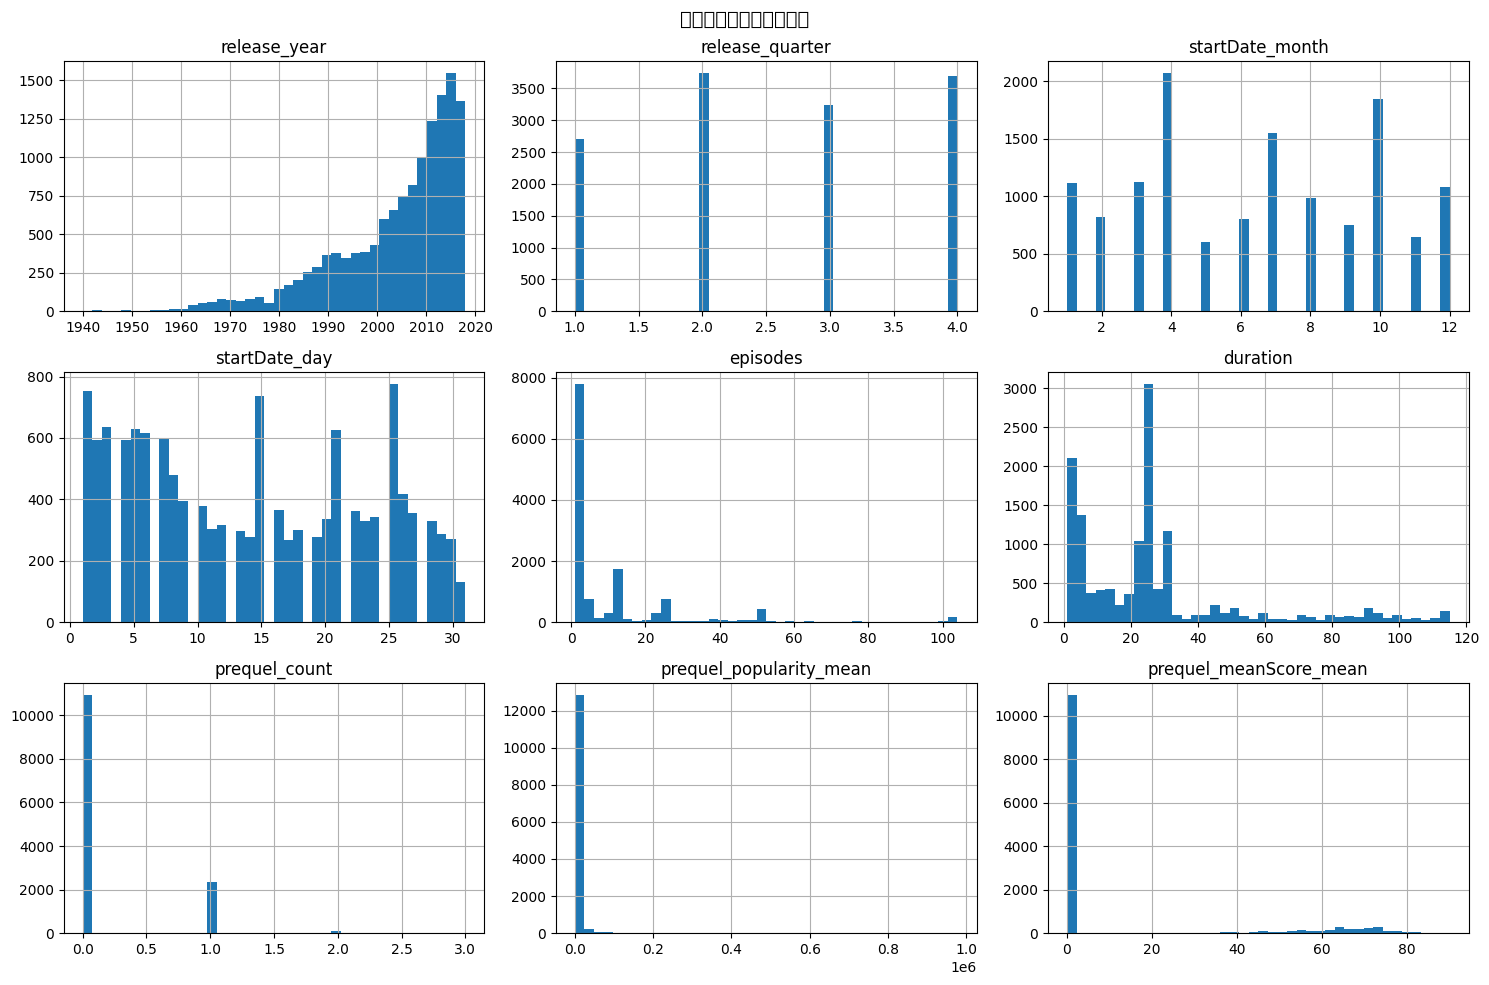

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, NUMERIC_COLS):
    train[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('數值欄位分佈（訓練集）', fontsize=14)
plt.tight_layout()
plt.show()

## 2. 標準化（Standardize）

**重要原則：** 使用 **訓練集** 的 mean/std 計算，再套用到 val/test，避免 data leakage。

`prequel_popularity_mean` 分佈高度右偏（max=977K），建議先做 `log1p` 再標準化。

In [6]:
STANDARDIZE_COLS = [
    'release_year', 'episodes', 'duration',
    'startDate_day',
    'prequel_count', 'prequel_meanScore_mean',
]
LOG1P_THEN_STANDARDIZE = ['prequel_popularity_mean']

scalers = {}

def fit_standardize(df, col, log1p=False):
    vals = df[col].dropna().copy()
    if log1p:
        vals = np.log1p(vals)
    return {'mean': vals.mean(), 'std': max(vals.std(), 1e-8), 'log1p': log1p}

def apply_standardize(series, scaler):
    s = series.copy()
    if scaler['log1p']:
        s = np.log1p(s.clip(lower=0))
    return (s - scaler['mean']) / scaler['std']

for col in STANDARDIZE_COLS:
    scalers[col] = fit_standardize(train, col)

for col in LOG1P_THEN_STANDARDIZE:
    scalers[col] = fit_standardize(train, col, log1p=True)

# 結果預覽
preview = train[STANDARDIZE_COLS + LOG1P_THEN_STANDARDIZE].copy()
for col, scaler in scalers.items():
    preview[col + '_scaled'] = apply_standardize(train[col], scaler)

pd.DataFrame(scalers).T

,mean,std,log1p
release_year,2004.1044,12.7437,False
episodes,11.0637,18.5792,False
duration,26.4180,25.3637,False
startDate_day,14.1072,9.0677,False
prequel_count,0.1898,0.4108,False
prequel_meanScore_mean,11.5579,25.0221,False
prequel_popularity_mean,1.5024,3.3219,True


In [ ]:
# 標準化後分佈確認
scaled_cols = [col + '_scaled' for col in scalers]
preview[scaled_cols].describe().T

## 3. Cyclical Encoding（sin/cos）

適用於有循環性的欄位，讓「首尾相接」的值在向量空間中也靠近。

| 欄位 | 週期 | 說明 |
|------|------|------|
| `release_quarter` | 4 | Q4 和 Q1 相鄰 |
| `startDate_month` | 12 | 12月和1月相鄰 |

> `startDate_day` 循環性語意弱，改為標準化處理。

In [ ]:
CYCLIC_COLS = {
    'release_quarter': 4,
    'startDate_month': 12,
}

def cyclic_encode(series, period):
    sin = np.sin(2 * np.pi * series / period)
    cos = np.cos(2 * np.pi * series / period)
    return sin, cos

cyclic_preview = pd.DataFrame(index=train.index)
for col, period in CYCLIC_COLS.items():
    sin_vals, cos_vals = cyclic_encode(train[col].fillna(train[col].median()), period)
    cyclic_preview[f'{col}_sin'] = sin_vals
    cyclic_preview[f'{col}_cos'] = cos_vals

cyclic_preview.head(5)

In [ ]:
# 視覺化 cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (col, period) in zip(axes, CYCLIC_COLS.items()):
    vals = np.arange(1, period + 1)
    sin_v = np.sin(2 * np.pi * vals / period)
    cos_v = np.cos(2 * np.pi * vals / period)
    ax.scatter(sin_v, cos_v, c=vals, cmap='hsv', s=100, zorder=3)
    for i, v in enumerate(vals):
        ax.annotate(str(v), (sin_v[i], cos_v[i]), textcoords='offset points', xytext=(5,5), fontsize=8)
    ax.set_title(f'{col}（週期={period}）')
    ax.set_xlabel('sin')
    ax.set_ylabel('cos')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
plt.suptitle('Cyclical Encoding 視覺化', fontsize=14)
plt.tight_layout()
plt.show()

## 4. One-hot Encoding

適用於無序類別欄位。**重要：** 類別清單從訓練集固定，val/test 用相同 mapping，遇到未知類別填 0。

In [ ]:
ONE_HOT_COLS = ['format', 'source', 'countryOfOrigin']

onehot_vocabs = {}
for col in ONE_HOT_COLS:
    vocab = sorted(train[col].dropna().unique().tolist())
    onehot_vocabs[col] = vocab
    print(f'{col:20s} ({len(vocab)} 類): {vocab}')

In [ ]:
def onehot_encode(df, col, vocab):
    dummies = pd.DataFrame(0, index=df.index, columns=[f'{col}_{v}' for v in vocab])
    for v in vocab:
        dummies[f'{col}_{v}'] = (df[col] == v).astype(int)
    return dummies

# 分佈確認
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ONE_HOT_COLS):
    train[col].value_counts().plot(kind='bar', ax=ax, rot=30)
    ax.set_title(col)
plt.suptitle('One-hot 欄位分佈（訓練集）', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Binary 欄位

直接使用 0/1，不需額外處理。

In [ ]:
BINARY_COLS = ['isAdult', 'is_sequel', 'has_sequel']

train[BINARY_COLS].mean().rename('positive_rate').to_frame().T

## 6. Multi-hot Encoding

### 6a. genres（固定 19 類）

In [ ]:
ALL_GENRES = [
    'Action', 'Adventure', 'Comedy', 'Drama', 'Ecchi', 'Fantasy',
    'Hentai', 'Horror', 'Mahou Shoujo', 'Mecha', 'Music', 'Mystery',
    'Psychological', 'Romance', 'Sci-Fi', 'Slice of Life', 'Sports',
    'Supernatural', 'Thriller'
]

def genres_multihot(series, vocab):
    mat = np.zeros((len(series), len(vocab)), dtype=np.float32)
    for i, val in enumerate(series):
        try:
            genres = ast.literal_eval(val) if pd.notna(val) else []
        except:
            genres = []
        for g in genres:
            if g in vocab:
                mat[i, vocab.index(g)] = 1.0
    return pd.DataFrame(mat, columns=[f'genre_{g.replace(" ","_")}' for g in vocab])

genres_df = genres_multihot(train['genres'], ALL_GENRES)
print(f'genres multi-hot shape: {genres_df.shape}')

# 出現頻率
freq = genres_df.sum().sort_values(ascending=False)
freq.plot(kind='bar', figsize=(14, 4), title='genres 出現頻率（訓練集）', rot=45)
plt.tight_layout()
plt.show()

### 6b. studios（top-K）

studios 數量龐大，只保留訓練集出現最頻繁的 top-K 家製作公司。K 的選擇影響特徵維度，以下分析覆蓋率。

In [ ]:
def parse_studios(val):
    if pd.isna(val):
        return []
    try:
        items = json.loads(val)
        return [s['node']['name'] for s in items if isinstance(s, dict) and 'node' in s]
    except:
        return []

all_studios = []
for val in train['studios']:
    all_studios.extend(parse_studios(val))

studio_cnt = Counter(all_studios)
print(f'總 studio 數: {len(studio_cnt)}')
print(f'出現 >= 10 次: {sum(1 for v in studio_cnt.values() if v >= 10)}')
print()

# 不同 K 值的覆蓋率
total_anime = len(train)
rows = []
for k in [10, 20, 30, 50, 100, 200]:
    top_k = {s for s, _ in studio_cnt.most_common(k)}
    covered = sum(
        1 for val in train['studios']
        if any(s in top_k for s in parse_studios(val))
    )
    rows.append({'K': k, 'covered_anime': covered, 'coverage_pct': covered / total_anime * 100})

pd.DataFrame(rows)

In [ ]:
# top-50 multi-hot 實作
TOP_K_STUDIOS = 50
top_studios = [s for s, _ in studio_cnt.most_common(TOP_K_STUDIOS)]
print(f'top-{TOP_K_STUDIOS} studios: {top_studios[:10]} ...')

def studios_multihot(series, vocab):
    mat = np.zeros((len(series), len(vocab)), dtype=np.float32)
    for i, val in enumerate(series):
        for s in parse_studios(val):
            if s in vocab:
                mat[i, vocab.index(s)] = 1.0
    return pd.DataFrame(mat, columns=[f'studio_{s.replace(" ","_")}' for s in vocab])

studios_df = studios_multihot(train['studios'], top_studios)
print(f'studios multi-hot shape: {studios_df.shape}')

## 7. 目標變數分佈

- `popularity`：右偏嚴重 → 先 `log1p` 再標準化
- `meanScore`：接近常態 → 直接標準化

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

train['popularity'].hist(bins=60, ax=axes[0, 0])
axes[0, 0].set_title('popularity（原始）')

np.log1p(train['popularity']).hist(bins=60, ax=axes[0, 1])
axes[0, 1].set_title('log1p(popularity)')

train['meanScore'].hist(bins=40, ax=axes[1, 0])
axes[1, 0].set_title('meanScore（原始）')

axes[1, 1].axis('off')

plt.suptitle('目標變數分佈', fontsize=14)
plt.tight_layout()
plt.show()

print('popularity stats:')
print(f'  mean={train["popularity"].mean():.1f}  std={train["popularity"].std():.1f}  skew={train["popularity"].skew():.2f}')
print('log1p(popularity) stats:')
lp = np.log1p(train['popularity'])
print(f'  mean={lp.mean():.4f}  std={lp.std():.4f}  skew={lp.skew():.2f}')
print('meanScore stats:')
print(f'  mean={train["meanScore"].mean():.2f}  std={train["meanScore"].std():.2f}  skew={train["meanScore"].skew():.2f}')

## 8. 最終特徵維度整理

確認所有編碼後的特徵維度，作為 MetaEncoder 的設計依據。

In [ ]:
feature_dims = {
    '數值標準化': len(STANDARDIZE_COLS) + len(LOG1P_THEN_STANDARDIZE),
    'cyclical（sin+cos×2欄）': len(CYCLIC_COLS) * 2,
    'one-hot format': len(onehot_vocabs['format']),
    'one-hot source': len(onehot_vocabs['source']),
    'one-hot countryOfOrigin': len(onehot_vocabs['countryOfOrigin']),
    'binary': len(BINARY_COLS),
    'genres multi-hot': len(ALL_GENRES),
    f'studios top-{TOP_K_STUDIOS} multi-hot': TOP_K_STUDIOS,
}

total = sum(feature_dims.values())
for name, dim in feature_dims.items():
    print(f'{name:40s} {dim:4d} 維')
print(f'{"─"*50}')
print(f'{"total":40s} {total:4d} 維')